# What is the most optimal skill to learn for Data Scientist?
Methodology
1. Group skills to determine median salary and likelihood of being in posting
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

In [7]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# loading Data 
from datasets import  load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
# cleaning data 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [8]:
df_DS_US = df[(df['job_title_short']=='Data Scientist') & (df['job_country'] == "United States")].copy()
df_DS_US = df_DS_US.dropna(subset='salary_year_avg')

In [9]:
df_DS_US_exploded = df_DS_US.explode('job_skills')
df_DS_US_exploded[['salary_year_avg','job_skills']].head(10)

,salary_year_avg,job_skills
100,228222.0,sql
100,228222.0,r
100,228222.0,python
100,228222.0,express
116,114000.0,r
116,114000.0,python
116,114000.0,sql
116,114000.0,t-sql
116,114000.0,hadoop
116,114000.0,spark


In [18]:
df_DS_Skills = df_DS_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by = 'count',ascending = False)
df_DS_Skills = df_DS_Skills.rename(columns={'count':'skill_count','median':'median_salary'})
DS_job_count = len(df_DS_US)
df_DS_Skills['skill_percent'] = df_DS_Skills['skill_count']/DS_job_count*100
skill_percent = 8
df_DS_Skills = df_DS_Skills[df_DS_Skills['skill_percent'] > skill_percent]
df_DS_Skills


,skill_count,median_salary,skill_percent
job_skills,,,
python,3358,131867.0,73.753569
sql,2463,134500.0,54.096200
r,2053,126000.0,45.091149
sas,1022,120000.0,22.446738
tableau,989,125000.0,21.721942
aws,768,134000.0,16.867999
spark,718,135959.5,15.769822
excel,490,124290.0,10.762135
tensorflow,474,149646.0,10.410718


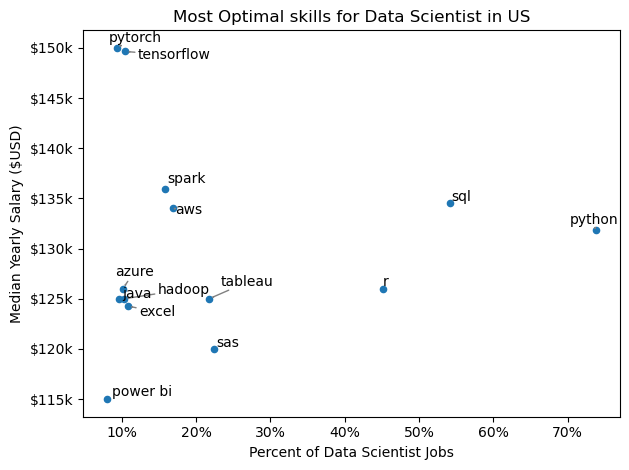

In [35]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
from matplotlib.ticker import  PercentFormatter
df_DS_Skills.plot(kind='scatter', x='skill_percent', y='median_salary')

texts = []
for i, txt in enumerate(df_DS_Skills.index):
    texts.append(
        plt.text(
            x=df_DS_Skills['skill_percent'].iloc[i],
            y=df_DS_Skills['median_salary'].iloc[i],
            s=txt
        )
    )

# adjust text positions
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
ax= plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos : f"${int(y/1000)}k"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))
plt.xlabel('Percent of Data Scientist Jobs')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal skills for Data Scientist in US')


plt.tight_layout()
plt.show()

In [37]:
df_tecnology = df['job_type_skills'].copy()
df_tecnology =df_tecnology.drop_duplicates()# remove duplicates
df_tecnology =df_tecnology.dropna()#remove null value

In [42]:
#combining all dicionary into one
technology_dict = {}
for row in df_tecnology:
    dict_row = ast.literal_eval(row) # convert string to dictionary
    for key,value in dict_row.items():
        if key in technology_dict:
            technology_dict[key]+=value
        else:
            technology_dict[key]=value
            
# removing dupicates by coverting into set and again into list
for key,value in technology_dict.items():
    technology_dict[key] = list(set(value))


In [47]:
# converting it into data fram
df_technology = pd.DataFrame(list(technology_dict.items()),columns=['technology','skills'])
df_technology = df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,spss
0,analyst_tools,datarobot
0,analyst_tools,looker
0,analyst_tools,spreadsheet
0,analyst_tools,power bi
...,...,...
9,sync,webex
9,sync,twilio
9,sync,zoom
9,sync,ringcentral


In [48]:
df_DS_Skills_high_demand =df_DS_Skills.merge(df_technology,left_on='job_skills',right_on='skills')
df_DS_Skills_high_demand

,skill_count,median_salary,skill_percent,technology,skills
0,3358,131867.0,73.753569,programming,python
1,2463,134500.0,54.096200,programming,sql
2,2053,126000.0,45.091149,programming,r
3,1022,120000.0,22.446738,analyst_tools,sas
4,1022,120000.0,22.446738,programming,sas
5,989,125000.0,21.721942,analyst_tools,tableau
6,768,134000.0,16.867999,cloud,aws
7,718,135959.5,15.769822,libraries,spark
8,490,124290.0,10.762135,analyst_tools,excel
9,474,149646.0,10.410718,libraries,tensorflow


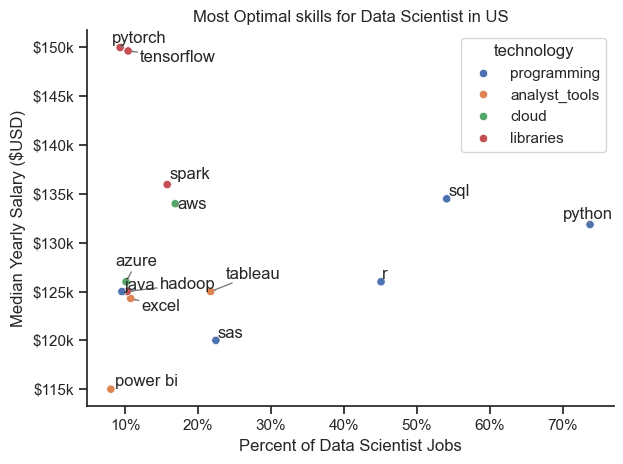

In [56]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
from matplotlib.ticker import  PercentFormatter

sns.set_theme(style='ticks')
# df_DS_Skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')
sns.scatterplot(data = df_DS_Skills_high_demand,x='skill_percent', y='median_salary',hue='technology')
texts = []
for i, txt in enumerate(df_DS_Skills.index):
    texts.append(
        plt.text(
            x=df_DS_Skills['skill_percent'].iloc[i],
            y=df_DS_Skills['median_salary'].iloc[i],
            s=txt
        )
    )

# adjust text positions
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
ax= plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos : f"${int(y/1000)}k"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))
plt.xlabel('Percent of Data Scientist Jobs')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal skills for Data Scientist in US')
sns.despine()

plt.tight_layout()
plt.show()